In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
plotsdir = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_AreaGrowthRate/Plots/'
datadir  = '//Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_AreaGrowthRate/Data/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
cmap = plt.cm.get_cmap('magma') #YlOrBr


No normalisation gain and loss

1
2
3
4
5


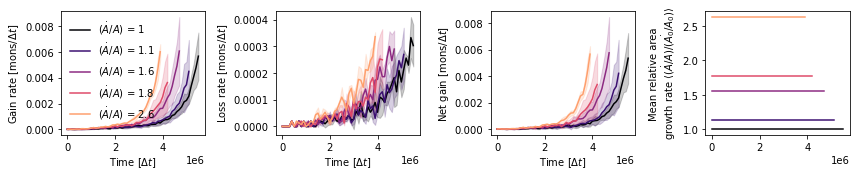

In [4]:
outdir = Path(datadir)
files = sorted(outdir.glob("rates_press_NoNorm*.dat"))

fig, ax = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True)
count = 0
for fp in files:
    df = pandas.read_csv(fp, sep=r"\s+", engine="python")
    t = df["time"].to_numpy()
    loss = df["loss"].to_numpy()
    loss_std = df["loss_std"].to_numpy()
    gain = df["gain"].to_numpy()
    gain_std = df["gain_std"].to_numpy()
    agr = df["areagrowthrate"].to_numpy()[0]
    net = np.subtract(gain,loss)
    net_std = np.add(gain_std,loss_std)
    clrs = count/5
    count+=1
    print(count)
    ax[0].plot(t, gain, label="$(\dot{A}/A)$ = " +str(np.round(agr,1)), color=cmap(clrs))
    ax[0].fill_between(t, gain-gain_std, gain+gain_std,color=cmap(clrs), alpha=0.2)
    ax[1].plot(t, loss, color=cmap(clrs))
    ax[1].fill_between(t, loss-loss_std, loss+loss_std,color=cmap(clrs), alpha=0.2)
    ax[2].plot(t,net, color=cmap(clrs))
    ax[2].fill_between(t, net-net_std, net+net_std,color=cmap(clrs), alpha=0.2)
    ax[3].plot(t, np.ones_like(t)*agr, color=cmap(clrs))

ax[0].legend(frameon=False)


ax[0].set_ylabel(r'Gain rate [mons$/\Delta t$]')
ax[1].set_ylabel(r'Loss rate [mons$/\Delta t$]')
ax[2].set_ylabel(r'Net gain [mons$/\Delta t$]')
ax[3].set_ylabel("Mean relative area\n"+r"growth rate $\langle (\dot{A}/A)/(\dot{A_{0}}/A_{0})\rangle$")
for i in range(3):
    ax[i].set_xlabel(r'Time [$\Delta t$]')
fig.tight_layout()
fig.savefig(plotsdir + 'Gain_Loss_Net_AreaGrowthRate.png',dpi = 300)

1
2
3
4
5


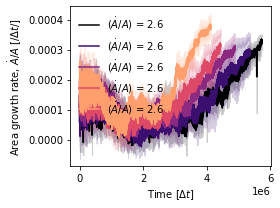

In [ ]:
fig2, ax2 = plt.subplots(1, figsize=(4, 3), sharex=True)
files = sorted(outdir.glob("AreaRate_*.dat"))

count = 0
for fp in files:
    df = pandas.read_csv(fp, sep=r"\s+", engine="python")
    t = df["time"].to_numpy()
    Adot = df["Adot"].to_numpy()
    Adot_std = df["Adot_std"].to_numpy()
    clrs = count/5
    count+=1
    print(count)
    ax2.plot(t, Adot, label="$(\dot{A}/A)$ = " +str(np.round(agr,1)), color=cmap(clrs))
    ax2.fill_between(t, Adot-Adot_std, Adot+Adot_std,color=cmap(clrs), alpha=0.2)

ax2.legend(frameon=False,loc = 'upper left')
ax2.set_ylabel(r'Area growth rate, $\dot{A}/A~[/\Delta t$]')
ax2.set_xlabel(r'Time [$\Delta t$]')
fig2.tight_layout()

Normalisation gain and loss by area

1
2
3
4
5


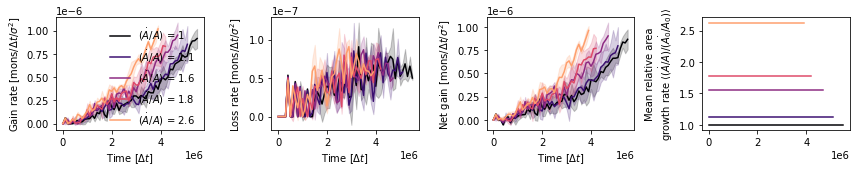

In [ ]:
outdir = Path(datadir)
files = sorted(outdir.glob("rates_press_perArea*.dat"))

fig, ax = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True)
count = 0
for fp in files:
    df = pandas.read_csv(fp, sep=r"\s+", engine="python")
    t = df["time"].to_numpy()
    loss = df["loss_PerArea"].to_numpy()
    loss_std = df["loss_std"].to_numpy()
    gain = df["gain_PerArea"].to_numpy()
    gain_std = df["gain_std"].to_numpy()
    agr = df["areagrowthrate"].to_numpy()[0]
    net = np.subtract(gain,loss)
    net_std = np.add(gain_std,loss_std)
    clrs = count/5
    count+=1
    print(count)
    ax[0].plot(t, gain, label="$(\dot{A}/A)$ = " +str(np.round(agr,1)), color=cmap(clrs))
    ax[0].fill_between(t, gain-gain_std, gain+gain_std,color=cmap(clrs), alpha=0.2)
    ax[1].plot(t, loss, color=cmap(clrs))
    ax[1].fill_between(t, loss-loss_std, loss+loss_std,color=cmap(clrs), alpha=0.2)
    ax[2].plot(t,net, color=cmap(clrs))
    ax[2].fill_between(t, net-net_std, net+net_std,color=cmap(clrs), alpha=0.2)
    ax[3].plot(t, np.ones_like(t)*agr, color=cmap(clrs))

ax[0].legend(frameon=False,loc = 'upper left')


ax[0].set_ylabel(r'Gain rate [mons$/\Delta t/\sigma^2$]')
ax[1].set_ylabel(r'Loss rate [mons$/\Delta t/\sigma^2$]')
ax[2].set_ylabel(r'Net gain [mons$/\Delta t/\sigma^2$]')
ax[3].set_ylabel("Mean relative area\n"+r"growth rate $\langle (\dot{A}/A)/(\dot{A_{0}}/A_{0})\rangle$")
for i in range(3):
    ax[i].set_xlabel(r'Time [$\Delta t$]')
fig.tight_layout()
fig.savefig(plotsdir + 'Gain_Loss_Net_AreaGrowthRate_PerArea.png',dpi = 300)

Normalisation gain and loss by area

1
2
3
4
5


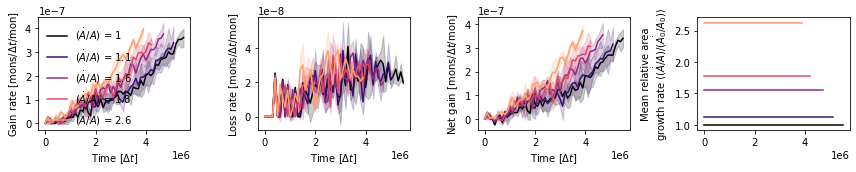

In [8]:
outdir = Path(datadir)
files = sorted(outdir.glob("rates_press_perMon*.dat"))

fig, ax = plt.subplots(1, 4, figsize=(12, 2.5), sharex=True)
count = 0
for fp in files:
    df = pandas.read_csv(fp, sep=r"\s+", engine="python")
    t = df["time"].to_numpy()
    loss = df["loss_PerMon"].to_numpy()
    loss_std = df["loss_std"].to_numpy()
    gain = df["gain_PerMon"].to_numpy()
    gain_std = df["gain_std"].to_numpy()
    agr = df["areagrowthrate"].to_numpy()[0]
    net = np.subtract(gain,loss)
    net_std = np.add(gain_std,loss_std)
    clrs = count/5
    count+=1
    print(count)
    ax[0].plot(t, gain, label="$(\dot{A}/A)$ = " +str(np.round(agr,1)), color=cmap(clrs))
    ax[0].fill_between(t, gain-gain_std, gain+gain_std,color=cmap(clrs), alpha=0.2)
    ax[1].plot(t, loss, color=cmap(clrs))
    ax[1].fill_between(t, loss-loss_std, loss+loss_std,color=cmap(clrs), alpha=0.2)
    ax[2].plot(t,net, color=cmap(clrs))
    ax[2].fill_between(t, net-net_std, net+net_std,color=cmap(clrs), alpha=0.2)
    ax[3].plot(t, np.ones_like(t)*agr, color=cmap(clrs))

ax[0].legend(frameon=False,loc = 'upper left')


ax[0].set_ylabel(r'Gain rate [mons$/\Delta t/$mon]')
ax[1].set_ylabel(r'Loss rate [mons$/\Delta t/$mon]')
ax[2].set_ylabel(r'Net gain [mons$/\Delta t/$mon]')
ax[3].set_ylabel("Mean relative area\n"+r"growth rate $\langle (\dot{A}/A)/(\dot{A_{0}}/A_{0})\rangle$")
for i in range(3):
    ax[i].set_xlabel(r'Time [$\Delta t$]')
fig.tight_layout()
fig.savefig(plotsdir + 'Gain_Loss_Net_AreaGrowthRate_PerMonomer.png',dpi = 300)